## wine quality


In [1]:
import pandas as pd
data=pd.read_csv('wine.csv')
y=data['quality']
x=data.drop(['quality'],axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [2]:
print(y_train)

582     5
626     5
1030    7
620     5
490     6
       ..
1130    6
1294    6
860     5
1459    7
1126    6
Name: quality, Length: 1199, dtype: int64


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(32,input_shape=(11,), activation='relu'))
model.add(Dense(6,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
y_train=y_train-3
y_test=y_test-3
print(np.unique(y_train))


c:\Users\HP\Desktop\SRM_KT\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[0 1 2 3 4 5]


In [4]:
model.fit(x_train,y_train,epochs=100,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3686 - loss: 2.2708 - val_accuracy: 0.4300 - val_loss: 1.7035
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4329 - loss: 1.5375 - val_accuracy: 0.4550 - val_loss: 1.3203
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4737 - loss: 1.3145 - val_accuracy: 0.5075 - val_loss: 1.2081
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4837 - loss: 1.2318 - val_accuracy: 0.5150 - val_loss: 1.1617
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5029 - loss: 1.1840 - val_accuracy: 0.5050 - val_loss: 1.1663
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5129 - loss: 1.1638 - val_accuracy: 0.5125 - val_loss: 1.1144
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5163 - loss: 1.1428 - val_accuracy: 0.5175 - val_loss: 1.1099
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5054 - loss: 1.1241 - val_accuracy: 0.5075 -

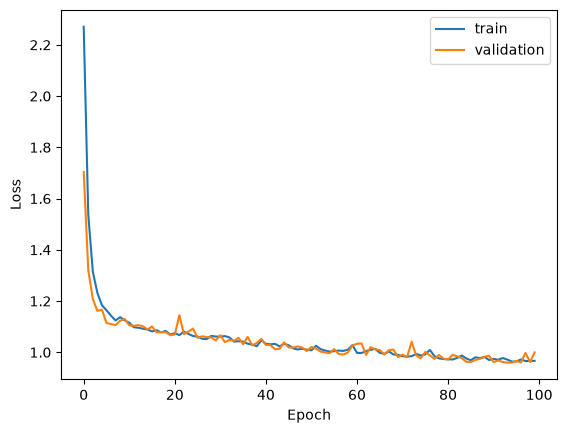

In [11]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'], label='train')
plt.plot(model.history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

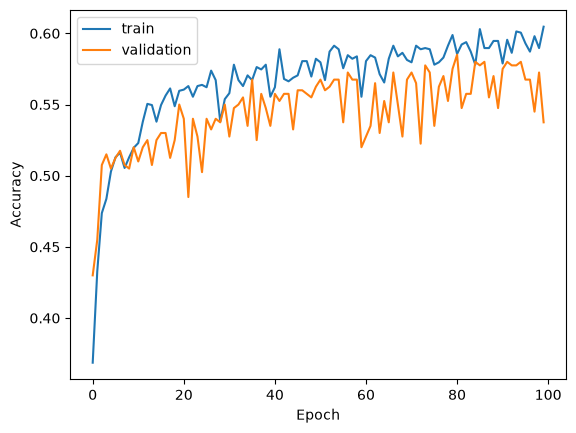

In [10]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'], label='train')
plt.plot(model.history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
pred=model.predict(x_test)
pred=np.argmax(pred,axis=1)
pred=pred+3
print(pred)
model.save('wine_quality_model.h5')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 


[5 5 6 5 6 5 5 5 5 6 6 5 6 5 5 7 5 5 7 5 5 5 6 7 5 5 6 5 5 6 5 5 5 5 5 5 6
 6 5 6 5 5 7 5 6 6 6 5 5 6 5 5 5 7 5 4 6 5 6 5 6 6 5 5 6 5 6 5 6 5 7 5 6 6
 7 5 6 5 6 6 5 7 5 5 6 7 5 6 7 5 6 7 5 6 5 6 5 6 5 5 5 5 6 6 6 6 6 5 6 6 7
 5 5 5 6 7 6 5 5 6 6 5 6 5 5 5 6 6 5 6 6 5 5 7 6 5 5 5 5 6 7 6 7 5 6 5 6 5
 6 5 6 6 5 6 6 6 5 6 5 6 7 5 6 5 5 6 5 5 5 5 5 5 7 6 7 6 7 5 5 5 5 6 5 7 5
 6 5 6 7 6 6 6 6 6 6 5 5 5 6 6 5 5 5 5 7 6 5 6 5 7 5 5 5 7 7 6 5 5 6 5 5 6
 7 6 5 5 5 7 5 5 5 5 7 6 5 6 5 6 5 5 5 5 6 6 5 5 6 5 7 5 6 5 5 5 5 5 5 6 5
 7 7 6 5 7 5 7 5 5 6 7 5 6 5 5 5 5 6 6 7 5 7 5 6 5 5 6 5 6 5 6 7 7 5 5 5 6
 5 7 6 7 5 5 6 5 5 5 6 6 7 7 5 6 6 5 5 6 5 5 6 5 6 6 6 5 5 5 6 5 4 6 6 7 5
 5 6 6 6 7 5 5 6 7 5 5 6 5 7 5 6 6 5 7 5 5 6 6 5 5 6 5 6 5 6 5 5 6 6 5 5 5
 5 5 6 5 5 6 5 6 5 5 5 6 7 5 6 6 6 5 5 6 5 6 5 6 6 6 7 5 5 6]


## House Rental

In [41]:
import pandas as pd
data=pd.read_csv('House_Rent_dataset.csv')
y=data['Rent']
x=data.drop(['Rent','Posted On','Floor','Area Locality'],axis=1)
import category_encoders as ce
encoder=ce.LeaveOneOutEncoder(return_df=True)
X=encoder.fit_transform(x,y)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x=scaler.fit_transform(X)

import pandas as pd
x=pd.DataFrame(x,columns=X.columns)




In [42]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [43]:
print(x_train)

      BHK      Size  Area Type      City  Furnishing Status  Tenant Preferred  \
1196  0.2  0.161452   0.997666  0.996587           0.989238          0.014338   
2215  0.2  0.077597   0.273144  0.184362           0.999533          0.017930   
1598  0.0  0.073842   0.273210  0.184476           0.009642          0.018043   
1532  0.2  0.129537   0.999842  0.184270           0.487101          0.587260   
1501  0.2  0.073842   0.273162  0.184392           0.999619          0.017960   
...   ...       ...        ...       ...                ...               ...   
4426  0.4  0.186483   0.999777  0.124548           0.487009          0.997794   
466   0.4  0.148936   0.273074  0.004130           0.009391          0.017809   
3092  0.2  0.098874   0.999824  0.138937           0.487075          0.998345   
3772  0.4  0.436796   0.999214  0.137951           0.486226          0.016828   
860   0.0  0.055069   0.999777  0.999715           0.487009          0.586822   

      Bathroom  Point of Co

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(64,input_shape=(8,),activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')
model.fit(x_train,y_train,epochs=100,batch_size=32,validation_data=(x_test,y_test))


Epoch 1/100


c:\Users\HP\Desktop\SRM_KT\srm\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 8091862016.0000 - val_loss: 5018459136.0000
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8086148096.0000 - val_loss: 5005905920.0000
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8062327296.0000 - val_loss: 4968590336.0000
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8008219648.0000 - val_loss: 4894765568.0000
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7912040448.0000 - val_loss: 4774665728.0000
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7771243520.0000 - val_loss: 4611278848.0000
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7593287680.0000 - val_loss: 4415947776.0000
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 7385070592.0000 - val_loss: 4192718848.0000
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7152546816.0000 - val_loss: 3955424000.0000
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6916

In [47]:
model.predict(x_test[1:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[24234.78 ],
       [55106.227],
       [41688.676],
       [78882.37 ]], dtype=float32)

## COMPUTER VISION

In [3]:
import cv2
print(cv2.__version__)

5.0.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt
image=np.full((1600,1600,3), 250, dtype='uint8')
image[400:500,400:1000]=[51,153,255]
image[600:700,400:1000]=[0,128,0]
cv2.imshow('image',image)
cv2.imwrite('image.jpg',image)
cv2.waitKey(5000)
cv2.destroyAllWindows()



In [5]:
image=cv2.imread('demo.jpg')
print(type(image))
#image=cv2.resize(image,(100,100))
image=cv2.flip(image,0)
r,b,g=cv2.split(image)
cv2.imshow('image',b)
cv2.waitKey(5000)
cv2.destroyAllWindows()

<class 'numpy.ndarray'>


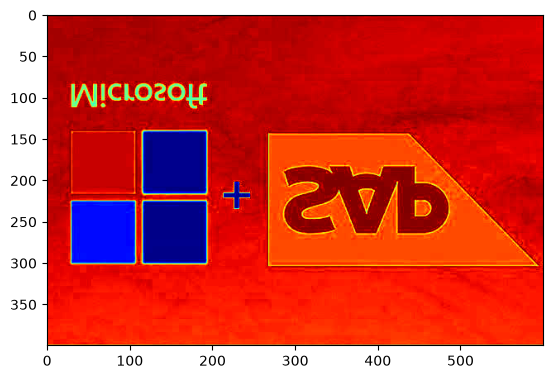

In [6]:
plt.imshow(r, cmap='jet')

In [26]:
image=cv2.imread('demo.jpg',0)

image=cv2.GaussianBlur(image,(5,5),0)
threshold_image,th=cv2.threshold(image,157,255,cv2.THRESH_TOZERO)
th=cv2.putText(th,'Thresholded Image',(100,300),cv2.FONT_HERSHEY_SIMPLEX,1,(25,255,25),2)
th=cv2.circle(th,(300,300),100,(255,0,0),5)
cv2.imshow('image',th)

cv2.waitKey(10000)
cv2.destroyAllWindows()

In [21]:
edge_detected_image=cv2.Canny(image,100,200)
cv2.imshow('image',edge_detected_image)
cv2.waitKey(10000)
cv2.destroyAllWindows()